# Exercise 1

In [1]:
import autograd.numpy as np
from autograd import grad
from autograd import value_and_grad
import matplotlib.pyplot as plt
from numpy import linalg
import pandas as pd

def gradient_descent(g,alpha,max_its,w):
    # compute gradient module using autograd
    gradient = grad(g)

    # run the gradient descent loop
    weight_history = [w.copy()]     # container for weight history
    cost_history = [g(w)]    # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_eval = gradient(w)

        # take gradient descent step
        w = w - alpha*grad_eval

        # record weight and cost
        weight_history.append(w.copy())
        cost_history.append(g(w))
    return weight_history,cost_history

In [43]:
def momentum_gradient_descent(g, alpha, beta, max_its, w):

    # Step 1: set up autograd value_and_grad function; returns cost and gradient together
    vg = value_and_grad(g)

    # Step 2: initialize containers for weight and cost history
    weight_history = [w]  # append initial weight
    cost0, grad0 = vg(w)  # evaluate initial cost and gradient
    cost_history = [cost0]  # append initial cost

    # Step 3: initialize momentum direction
    d = -grad0

    # Step 4: main momentum gradient descent loop
    for k in range(max_its):

        w = w + alpha * d   # evaluate the new weight
        cost, grad = vg(w)  # evaluate new cost and gradient at updated w

        d = beta * d + (1 - beta) * (-grad)  # update momentum direction

        weight_history.append(w)   # record weight
        cost_history.append(cost)  # record cost

    return weight_history, cost_history

In [14]:
C = np.array([[0.5,0],[0,9.75]])
g = lambda w: (np.dot(np.dot(w.T,C),w))

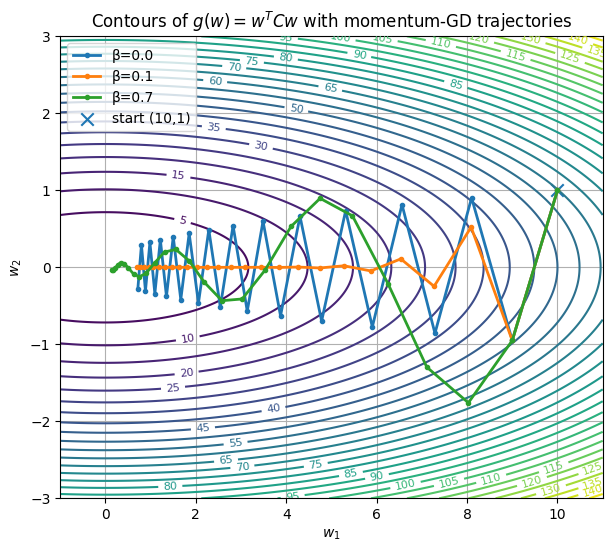

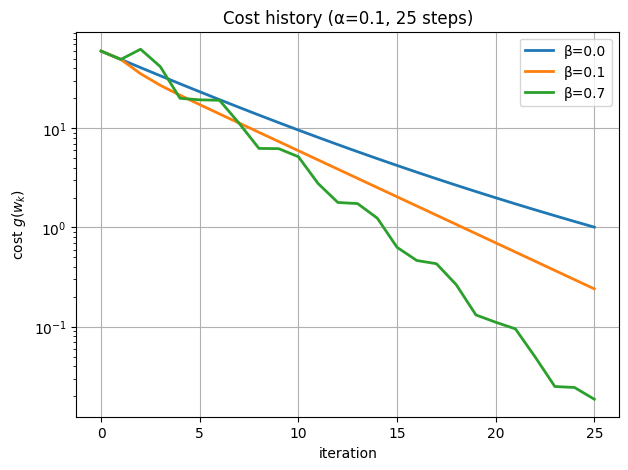

In [17]:
alpha = 0.1
max_its = 25
betas = [0.0, 0.1, 0.7]
w0 = np.array([10.0, 1.0])

results = {}
for beta in betas:
    W, J = momentum_gradient_descent(g, alpha, beta, max_its, w0.copy())
    results[beta] = (W, J)

# ---- contour plot of g(w) with trajectories ----
# choose a grid that covers the trajectories (here: a safe fixed range)
w1 = np.linspace(-1, 11, 400)
w2 = np.linspace(-3,  3, 400)
W1, W2 = np.meshgrid(w1, w2)

Z = 0.5*W1**2 + 9.75*W2**2  # since C is diagonal

plt.figure(figsize=(7, 6))
cs = plt.contour(W1, W2, Z, levels=30)
plt.clabel(cs, inline=True, fontsize=8)

for beta in betas:
    W, _ = results[beta]
    W = np.array(W)   # ← ADD THIS LINE
    plt.plot(W[:, 0], W[:, 1], marker='o', markersize=3, linewidth=2, label=f"β={beta}")

plt.scatter([w0[0]], [w0[1]], marker='x', s=80, label="start (10,1)")
plt.xlabel("$w_1$")
plt.ylabel("$w_2$")
plt.title(f"Contours of $g(w)=w^T C w$ with momentum-GD trajectories")
plt.legend()
plt.grid(True)
plt.show()

# ---- cost history plot ----
plt.figure(figsize=(7, 5))
for beta in betas:
    _, J = results[beta]
    plt.plot(np.arange(len(J)), J, linewidth=2, label=f"β={beta}")

plt.xlabel("iteration")
plt.ylabel("cost $g(w_k)$")
plt.title("Cost history (α=0.1, 25 steps)")
plt.yscale("log")  # optional but usually helpful for quadratics
plt.legend()
plt.grid(True)
plt.show()

# Exercise 2

In [54]:
def normalized_gradient_descent(g,alpha,max_its,w):
    # compute gradient module using autograd
    gradient = grad(g)

    # run the gradient descent loop
    weight_history = [w.copy()]     # container for weight history
    cost_history = [g(w)]    # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_eval = gradient(w)
        grad_eval_norm = linalg.norm(grad_eval)

        # take gradient descent step
        w = w - alpha/(grad_eval_norm**2 + 1e-8)  * grad_eval

        # record weight and cost
        weight_history.append(w.copy())
        cost_history.append(g(w))
    return weight_history,cost_history

In [45]:
g = lambda w: np.tanh(4*w[0] + 4*w[1]) + np.maximum(1.0, 0.4*w[0]**2) + 1.0

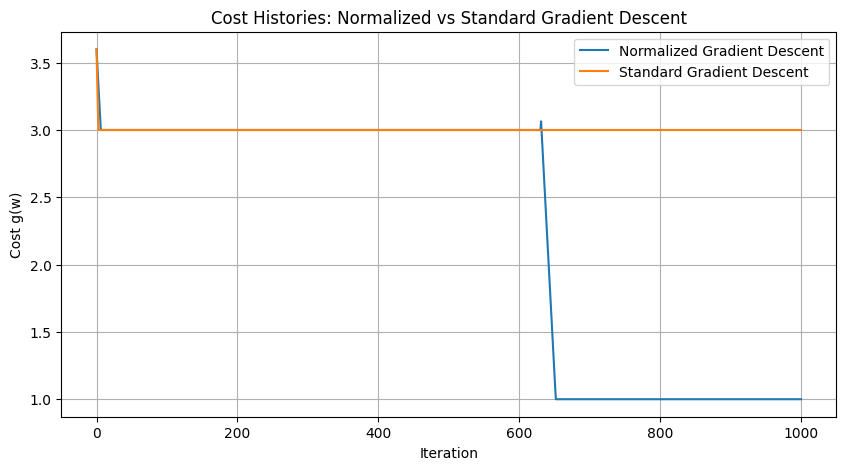

In [61]:
w0 = np.array([2.0,2.0])
alpha = 0.1
max_its = 1000

# run normalized gradient descent and standard gradient descent
norm_weights, norm_costs = normalized_gradient_descent(g, alpha, max_its, w0)
std_weights, std_costs = gradient_descent(g, alpha, max_its, w0)

# plot the cost histories
plt.figure(figsize=(10,5))
plt.plot(norm_costs, label='Normalized Gradient Descent')
plt.plot(std_costs, label='Standard Gradient Descent')
plt.xlabel('Iteration')
plt.ylabel('Cost g(w)')
#plt.xscale('log')
#plt.yscale('log')
plt.title('Cost Histories: Normalized vs Standard Gradient Descent')
plt.legend()
plt.grid()
plt.show()

# Exercise 3

In [74]:
csvname = 'student_debt_data.csv'  # import the dataset
data = np.asarray(pd.read_csv(csvname, header=None))
x = data[:,0]  # "year" vector
x.shape = (len(x),1)  # reshape to a column vector
o = np.ones((len(x),1))  # intercept vector
x_new = np.concatenate((o,x),axis = 1)
y = data[:,1]

n = x_new.shape[1]          # number of parameters/features = 2
A = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        A[i, j] = np.sum(x_new[:, i] * x_new[:, j])

inv_A = np.linalg.pinv(A)

print(A)
print(inv_A)

[[4.00000000e+01 8.03650000e+04]
 [8.03650000e+04 1.61463664e+08]]
[[ 1.20973801e+04 -6.02120582e+00]
 [-6.02120582e+00  2.99692942e-03]]


[[4.00000000e+01 8.03650000e+04]
 [8.03650000e+04 1.61463664e+08]]


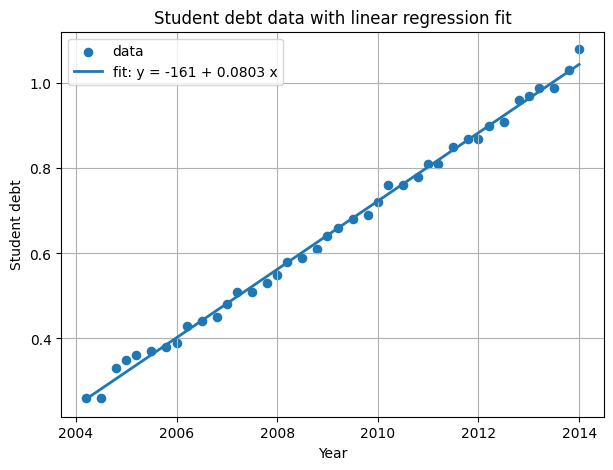

In [73]:
# build "year" matrix X = [1, x]
X = np.column_stack((np.ones(len(x)), x))

# solve normal equations (3.1)
A = X.T @ X
b = X.T @ y
w = np.linalg.pinv(A) @ b
w0, w1 = w[0], w[1]

# predictions on the given x's
y_hat = w0 + w1 * x

# (optional) for a smooth fitted line across the range
x_line = np.linspace(x.min(), x.max(), 200)
y_line = w0 + w1 * x_line

# plot
plt.figure(figsize=(7,5))
plt.scatter(x, y, s=35, label="data")
plt.plot(x_line, y_line, linewidth=2, label=f"fit: y = {w0:.3g} + {w1:.3g} x")
plt.xlabel("Year")
plt.ylabel("Student debt")
plt.title("Student debt data with linear regression fit")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# predict the student debt at 2050
year_2050 = 2050
debt_2050 = w0 + w1 * year_2050
print(f"Predicted student debt in {year_2050}: {debt_2050:.2f}")

Predicted student debt in 2050: 3.94


# Exercise 4

In [19]:
def gradient_descent(g,alpha,max_its,w):
    # compute gradient module using autograd
    gradient = grad(g)

    # run the gradient descent loop
    weight_history = [w.copy()]     # container for weight history
    cost_history = [g(w)]    # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_eval = gradient(w)

        # take gradient descent step
        w = w - alpha*grad_eval

        # record weight and cost
        weight_history.append(w.copy())
        cost_history.append(g(w))
    return weight_history,cost_history

In [20]:
# import the dataset. Note you need to take the log of the imported data
csvname = 'kleibers_law_data.csv'
data = np.loadtxt(csvname,delimiter=',')
x = np.array(data[:-1,:])
y = np.array(data[-1:,:])
print(x)

[[1370.    1250.       7.4   ...    1.975    4.12     4.38 ]]


In [28]:
# take the log of x and y
log_x = np.log(x[0])
log_y = np.log(y[0])

def model(w, log_x):  # returns log(y) given w and log(x)
    return w[0] + (log_x * w[1])

def least_squares(w):
    preds = model(w, log_x)
    res = log_y - preds
    return np.mean(res**2)  # used mean squared error because sum was too large; kept encountering overflow issues
    #return np.sum(res**2)

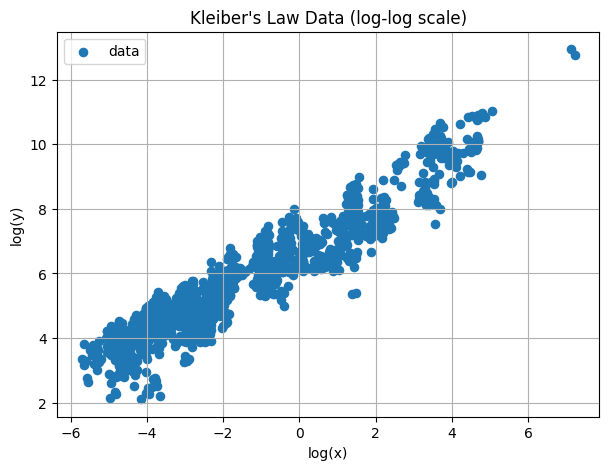

In [29]:
# plot log_x and log_y
plt.figure(figsize=(7,5))
plt.scatter(log_x, log_y, s=35, label="data")
plt.xlabel("log(x)")
plt.ylabel("log(y)")
plt.title("Kleiber's Law Data (log-log scale)")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
alpha = 0.01
max_its = 1000
w0 = np.array([1, 0.8])  # initial guess for [w0, w1]

print("P =", len(log_x))
print("initial cost (sum) =", np.sum((log_y - model(w0, log_x))**2))
print("initial cost (mean) =", np.mean((log_y - model(w0, log_x))**2))

weights, costs = gradient_descent(least_squares, alpha, max_its, w0)

P = 1498
initial cost (sum) = 55958.10880299803
initial cost (mean) = 37.35521281909081


In [56]:
# save fit parameters
w0 = weights[-1][0]
w1 = weights[-1][1]
print(w0, w1)

6.814725260584772 0.6528102583170055


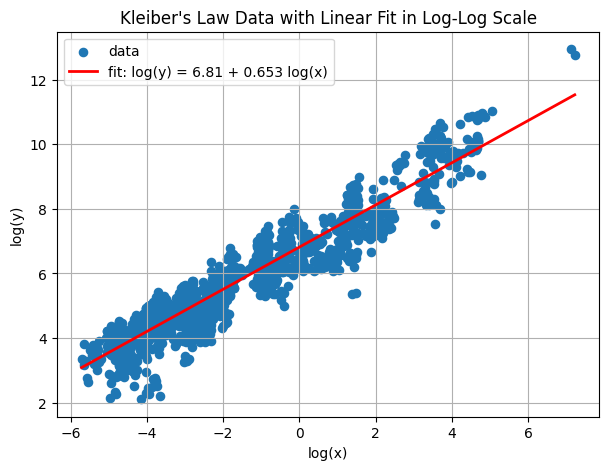

In [57]:
# plot the fitted line along with data
plt.figure(figsize=(7,5))
plt.scatter(log_x, log_y, s=35, label="data")
log_x_line = np.linspace(log_x.min(), log_x.max(), 200)
log_y_line = []

for val in log_x_line:
    log_y_line.append(w0 + w1 * val)

plt.plot(log_x_line, log_y_line, color='red', linewidth=2, label=f"fit: log(y) = {w0:.3g} + {w1:.3g} log(x)")
plt.xlabel("log(x)")
plt.ylabel("log(y)")
plt.title("Kleiber's Law Data with Linear Fit in Log-Log Scale")
plt.legend()
plt.grid(True)
plt.show()

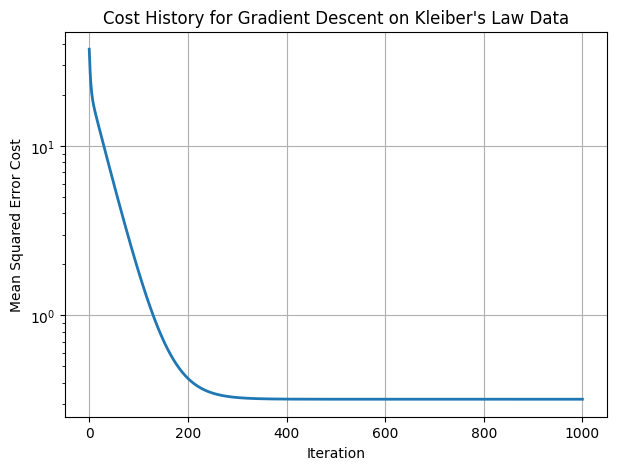

In [58]:
# make plot of cost history over iterations
plt.figure(figsize=(7,5))
plt.plot(costs, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error Cost")
plt.title("Cost History for Gradient Descent on Kleiber's Law Data")
plt.yscale("log")
plt.grid(True)
plt.show()

In [61]:
# approximate the metabolic rate y for an animal of mass x=10 kg
mass_10kg = 10.0
log_mass_10kg = np.log(mass_10kg)
log_metabolic_rate_10kg = w0 + w1 * log_mass_10kg
metabolic_rate_10kg = np.exp(log_metabolic_rate_10kg)
print(f"Approximate metabolic rate for an animal of mass {mass_10kg} kg: {metabolic_rate_10kg:.2f} (units of KJ/day)")
metabolic_rate_j = metabolic_rate_10kg * 1000  # convert KJ to J
calories = metabolic_rate_j / 4.184  # convert J to calories
print(f"Approximate metabolic rate for an animal of mass {mass_10kg} kg: {calories:.2f} calories/day")

Approximate metabolic rate for an animal of mass 10.0 kg: 4096.45 (units of KJ/day)
Approximate metabolic rate for an animal of mass 10.0 kg: 979075.45 calories/day
